In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from mpl_toolkits.mplot3d import Axes3D

In [35]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/Mall_Customers.csv')
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [36]:
df = df.drop(['CustomerID', 'Gender'], axis=1)
df.head(3)

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6


In [37]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,0.019231,0.000000,0.387755
1,0.057692,0.000000,0.816327
2,0.038462,0.008197,0.051020
3,0.096154,0.008197,0.775510
4,0.250000,0.016393,0.397959


In [38]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Create DataFrame with scaled data
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

print("Scaled data statistics:")
print(df.describe())

Scaled data statistics:
              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.000000               73.000000
max     70.000000          137.000000               99.000000


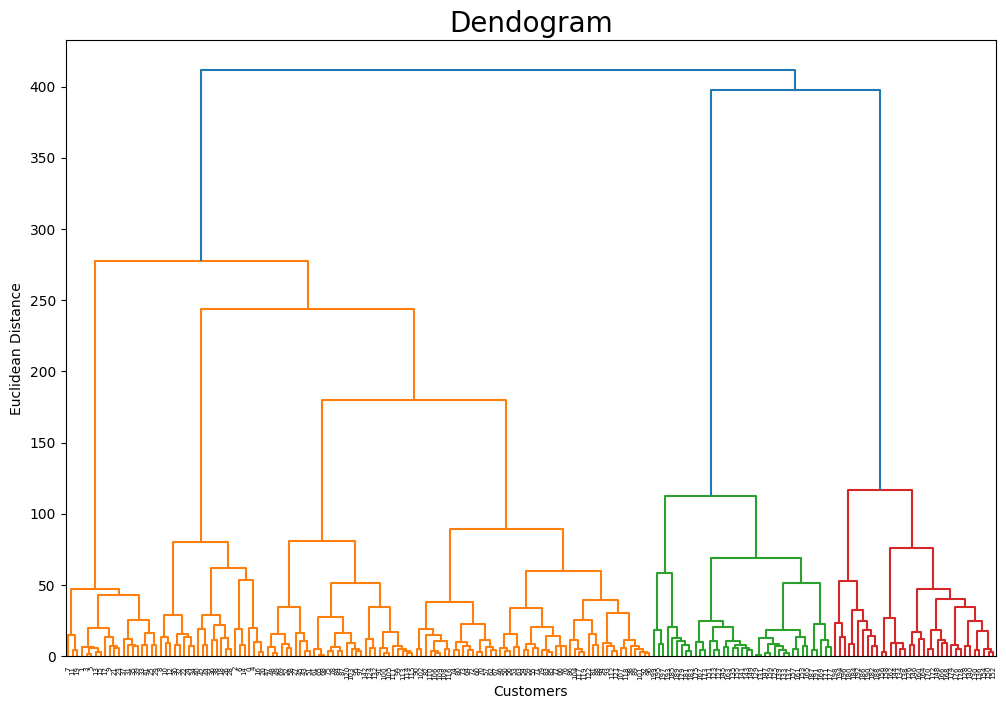

In [39]:
# Import

import scipy.cluster.hierarchy as sch

plt.rcParams['figure.figsize'] = (12, 8)

dendrogram = sch.dendrogram(sch.linkage(df, method = 'ward'))
plt.title('Dendogram', fontsize = 20)
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()


In [40]:
from sklearn.decomposition import PCA

# 12. How many principal components will it take to achieve at least 80% of explained variance?
pca = PCA()
pca_result = pca.fit_transform(df)

# Calculate cumulative explained variance
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Find the number of components needed for at least 80% variance
n_components_80 = np.argmax(cumulative_explained_variance >= 0.80) + 1

print(f"Number of principal components needed for at least 80% explained variance: {n_components_80}")

Number of principal components needed for at least 80% explained variance: 2


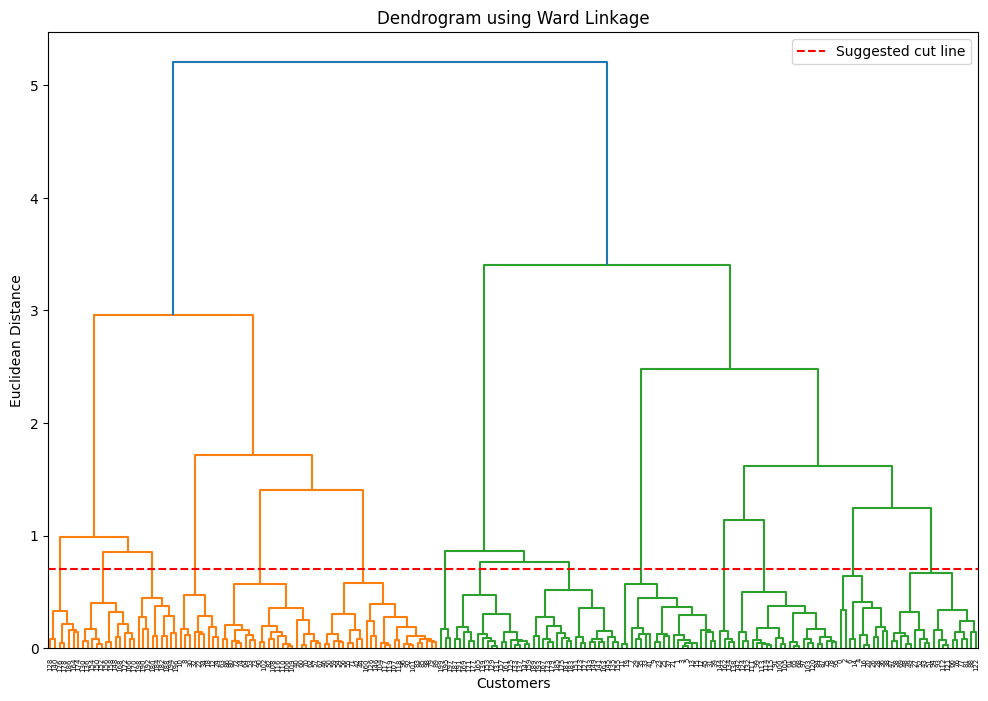

ANSWER 13: Based on the dendrogram, the most optimal number of clusters appears to be 3-5.
Looking at the longest vertical lines without horizontal crossings, 5 clusters seems optimal.


In [41]:
# 13. Based on the dendrogram, what is the most optimal number of clusters?

plt.figure(figsize=(12, 8))
dendrogram = sch.dendrogram(sch.linkage(df_scaled, method='ward'))
plt.title('Dendrogram using Ward Linkage')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.axhline(y=0.7, color='r', linestyle='--', label='Suggested cut line')
plt.legend()
plt.show()

# Based on the dendrogram, determine optimal number of clusters
print("ANSWER 13: Based on the dendrogram, the most optimal number of clusters appears to be 3-5.")
print("Looking at the longest vertical lines without horizontal crossings, 5 clusters seems optimal.")

In [42]:
# Perform hierarchical clustering with optimal clusters
optimal_clusters = 5
hc = AgglomerativeClustering(n_clusters=optimal_clusters, linkage='ward')
clusters = hc.fit_predict(df_scaled)

# Add cluster labels to the scaled dataframe
df_scaled['Cluster'] = clusters
df['Cluster'] = clusters

print("Cluster distribution:")
print(df_scaled['Cluster'].value_counts().sort_index())

Cluster distribution:
Cluster
0    56
1    56
2    39
3    28
4    21
Name: count, dtype: int64


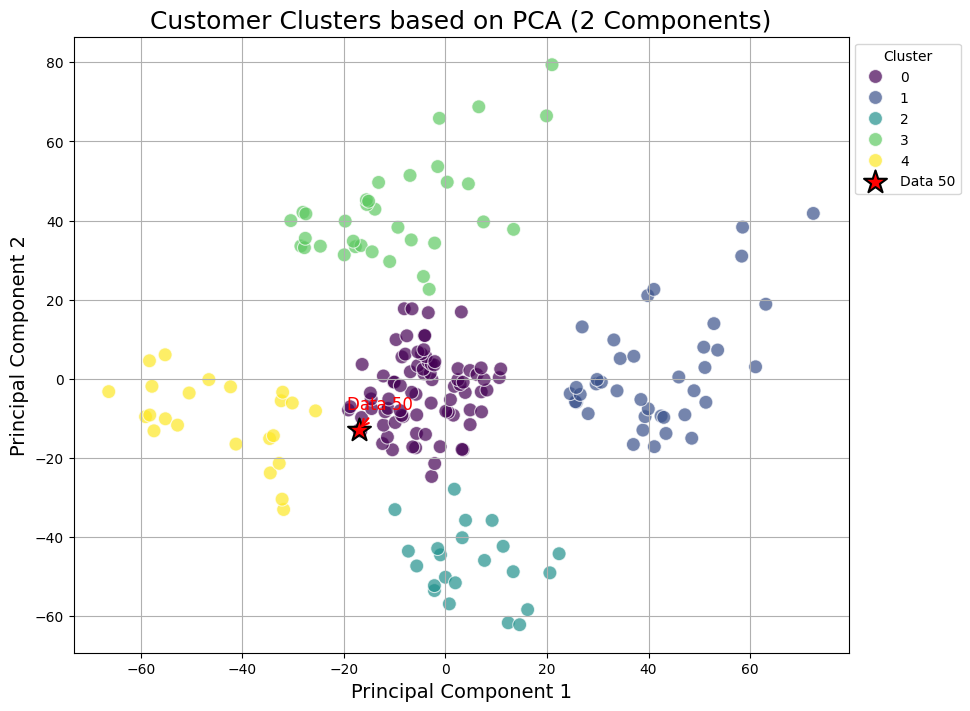

In [46]:
from sklearn.cluster import KMeans

# Apply K-Means clustering with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_result[:, :2])

# Add the cluster labels to the scaled DataFrame
df_scaled['Cluster'] = clusters

# Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=clusters, palette='viridis', s=100, alpha=0.7)

# Highlight and annotate data point 50 (index 49) with a star marker
plt.scatter(pca_result[49, 0], pca_result[49, 1], color='red', s=300, edgecolors='black', linewidth=1.5, marker='*', label='Data 50')
plt.annotate('Data 50', (pca_result[49, 0], pca_result[49, 1]),
             textcoords="offset points", xytext=(15, 15),
             ha='center', fontsize=12, color='red',
             arrowprops=dict(arrowstyle='->', color='red', linewidth=1.5))

plt.title('Customer Clusters based on PCA (2 Components)', fontsize=18)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.legend(title='Cluster', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

In [47]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import plotly.express as px

# Perform PCA with 3 components
pca_3d = PCA(n_components=3)
pca_result_3d = pca_3d.fit_transform(df_scaled.drop('Cluster', axis=1))

# Apply K-Means clustering with 5 clusters on 3 components
kmeans_3d = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_3d = kmeans_3d.fit_predict(pca_result_3d)

# Add the cluster labels to a new DataFrame for 3D plotting
df_3d = pd.DataFrame(pca_result_3d, columns=['PC1', 'PC2', 'PC3'])
df_3d['Cluster'] = clusters_3d
df_3d['Data Point'] = df_3d.index + 1 # Add original data point index

# Create 3D scatter plot
fig = px.scatter_3d(df_3d, x='PC1', y='PC2', z='PC3',
                    color='Cluster',
                    title='Customer Clusters based on PCA (3 Components)',
                    labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2', 'PC3': 'Principal Component 3'},
                    hover_data=['Data Point']) # Show data point index on hover

# Highlight Data 50 with a black circle
fig.add_scatter3d(x=[df_3d['PC1'][49]], y=[df_3d['PC2'][49]], z=[df_3d['PC3'][49]],
                  mode='markers',
                  marker=dict(color='red', size=10, symbol='circle', line=dict(color='black', width=2)), # Ensure black circle with border
                  name='Data 50')

fig.show()